Original-Statistiken für Ziffer 7:
  Min: 0.0
  Max: 255.0
  Mittelwert: 35.43
  Std: 82.21
  Median: 0.00
  Q1: 0.00
  Q3: 0.00
  IQR: 0.00

Berechne Statistiken für jede Skalierung:

Erstelle Plot für: Original (keine Skalierung)


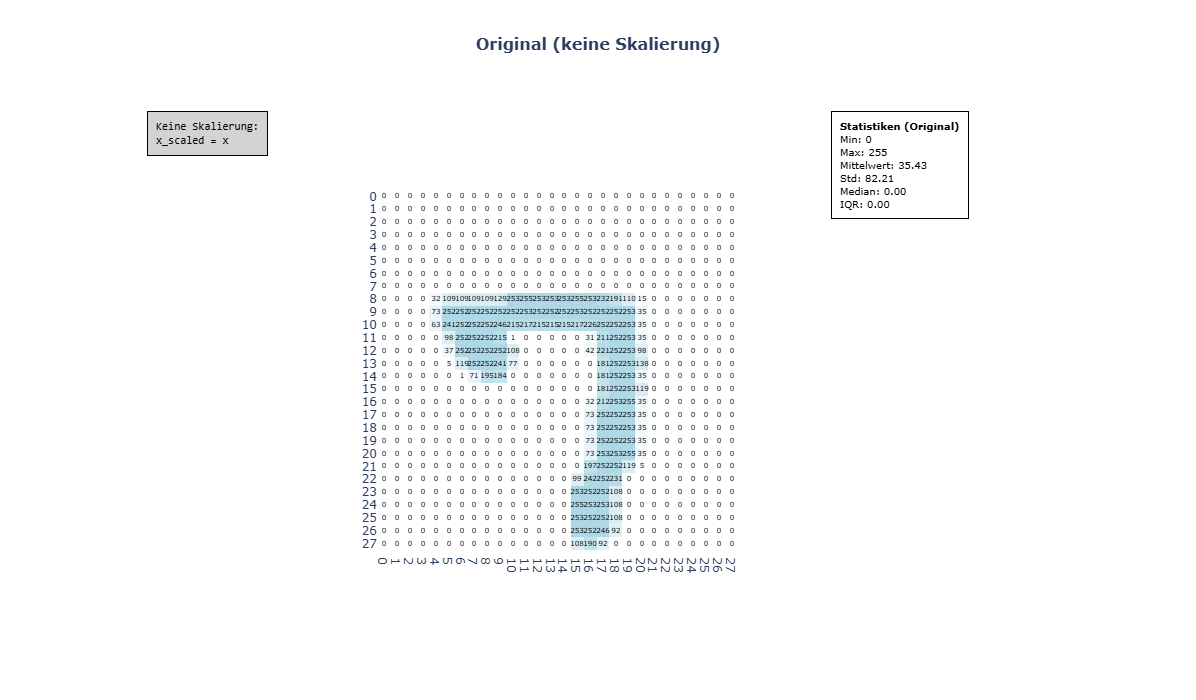


Erstelle Plot für: DIV/255


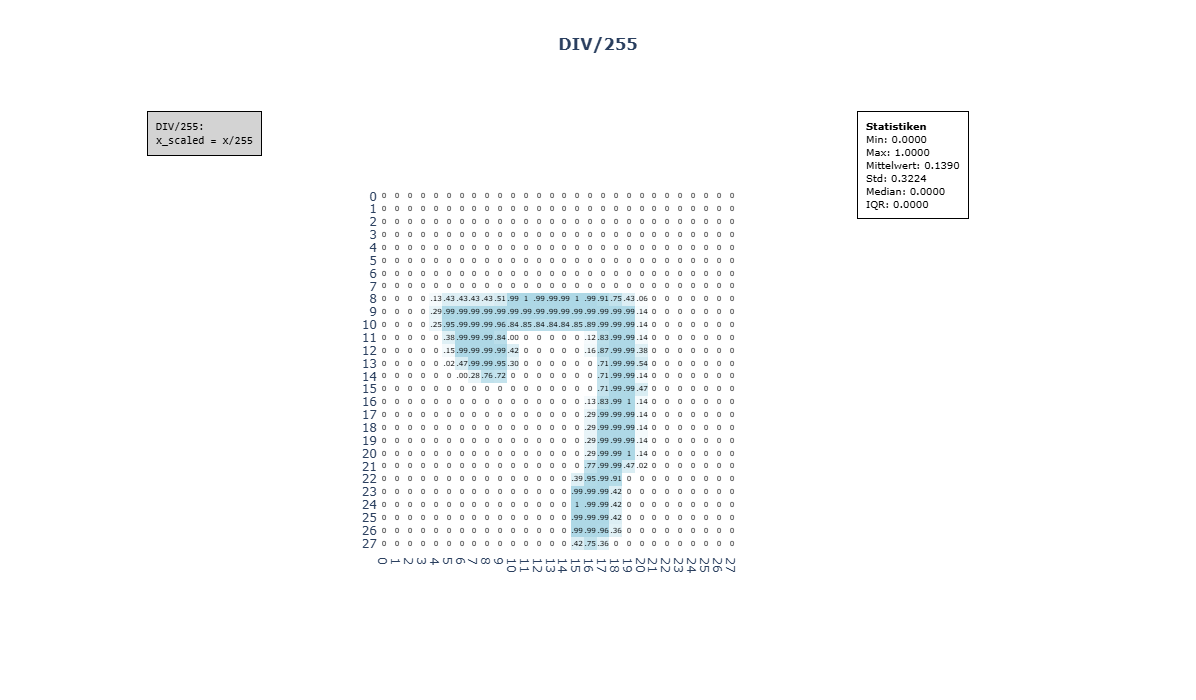


Erstelle Plot für: MinMax Scaling


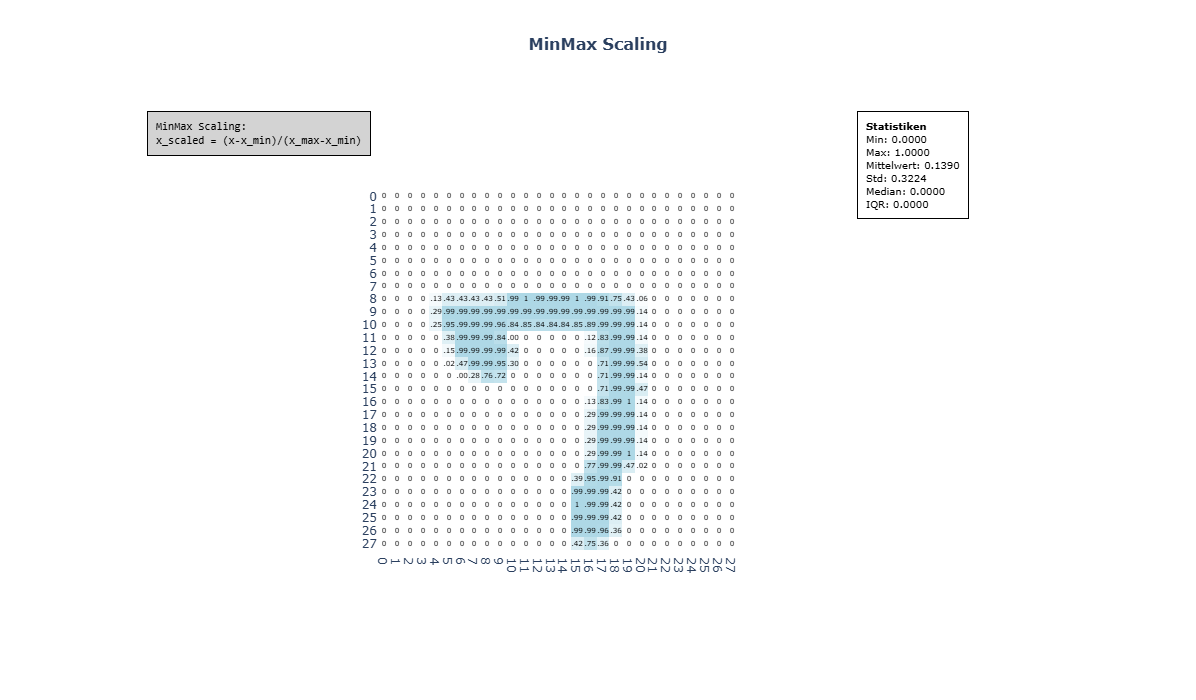


Erstelle Plot für: Standard Scaling (Z-Score)


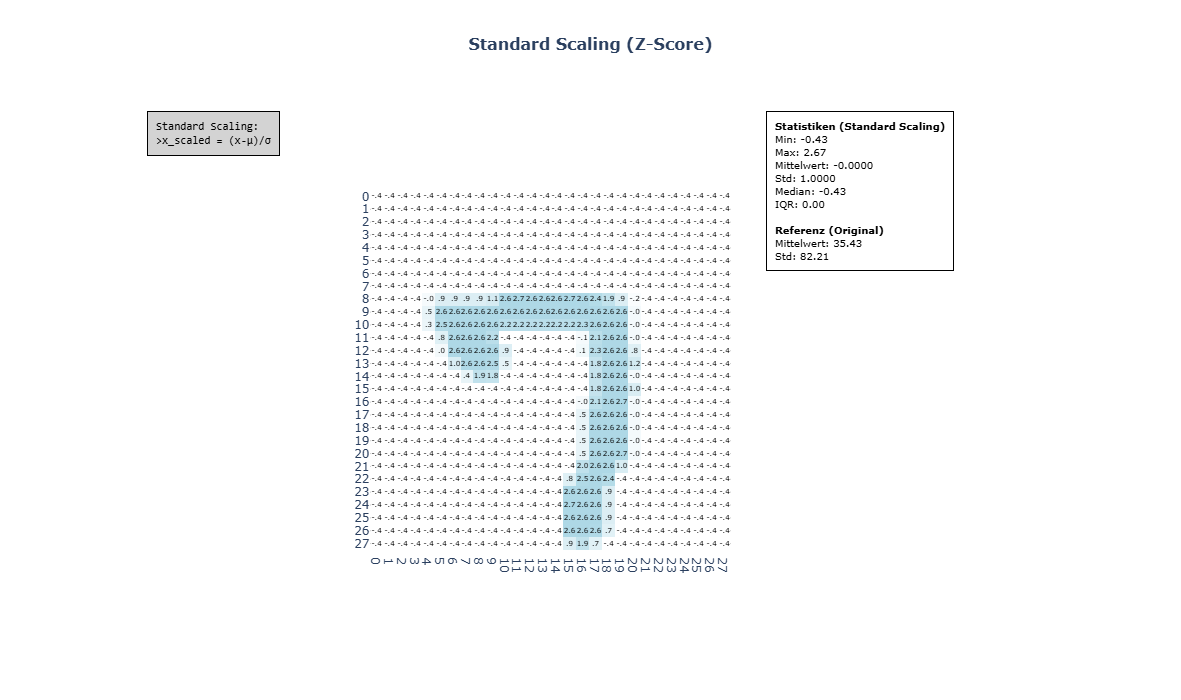


Erstelle Plot für: Robust Scaling
  Robust Scaling: Median=0.000000, IQR=0.000000
    Erwartet: Median nahe 0, IQR nahe 1


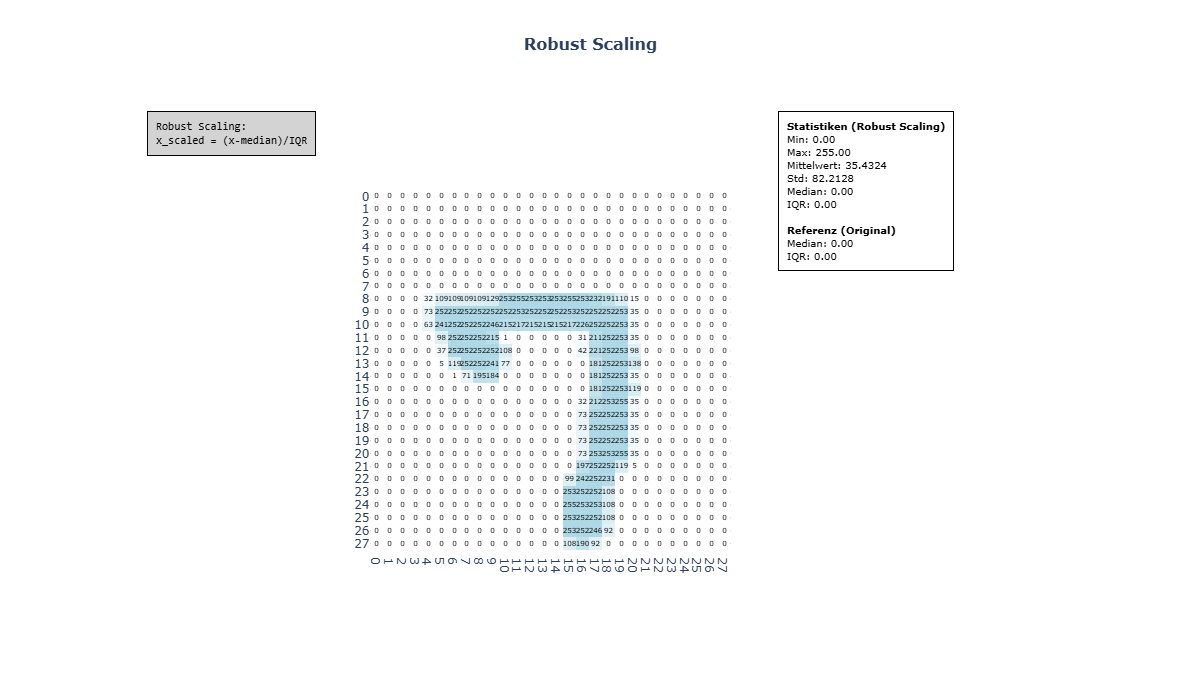

In [22]:
# V4 - SCHNELLE Version mit Heatmap texttemplate (korrigierte Statistiken)
import numpy as np
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from tensorflow.keras.datasets import mnist

# MNIST Daten laden
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Erste Ziffer 7 finden
#idx = np.where(y_train == 7)[0][0]   # Median und IQR entartet zu 0
#original_data = X_train[idx].astype(np.float64)
indices_7 = np.where(y_train == 7)[0]
idx = indices_7[20]
original_data = X_train[idx].astype(np.float64)
# Berechne Statistiken der Originaldaten (für Referenz)
orig_flat = original_data.flatten()
orig_min = np.min(orig_flat)
orig_max = np.max(orig_flat)
orig_mean = np.mean(orig_flat)
orig_std = np.std(orig_flat)
orig_median = np.median(orig_flat)
orig_q1 = np.percentile(orig_flat, 25)
orig_q3 = np.percentile(orig_flat, 75)
orig_iqr = orig_q3 - orig_q1

print("="*50)
print("Original-Statistiken für Ziffer 7:")
print(f"  Min: {orig_min}")
print(f"  Max: {orig_max}")
print(f"  Mittelwert: {orig_mean:.2f}")
print(f"  Std: {orig_std:.2f}")
print(f"  Median: {orig_median:.2f}")
print(f"  Q1: {orig_q1:.2f}")
print(f"  Q3: {orig_q3:.2f}")
print(f"  IQR: {orig_iqr:.2f}")
print("="*50)

# Standardisierungsfunktionen definieren
def div255_scaling(data):
    return data / 255.0

def minmax_scaling(data):
    scaler = MinMaxScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).reshape(28, 28)

def standard_scaling(data):
    scaler = StandardScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).reshape(28, 28)

def robust_scaling(data):
    scaler = RobustScaler()
    return scaler.fit_transform(data.reshape(-1, 1)).reshape(28, 28)

# Alle Skalierungen anwenden
scaled_data = {
    'Original (keine Skalierung)': original_data,
    'DIV/255': div255_scaling(original_data),
    'MinMax Scaling': minmax_scaling(original_data),
    'Standard Scaling (Z-Score)': standard_scaling(original_data),
    'Robust Scaling': robust_scaling(original_data)
}

# Kurze Formeln für die Textbox mit <br> für Zeilenumbruch
scaling_formulas = {
    'Original (keine Skalierung)': 'Keine Skalierung:<br>x_scaled = x',
    'DIV/255': 'DIV/255:<br>x_scaled = x/255',
    'MinMax Scaling': 'MinMax Scaling:<br>x_scaled = (x-x_min)/(x_max-x_min)',
    'Standard Scaling (Z-Score)': 'Standard Scaling:<br>>x_scaled = (x-μ)/σ',
    'Robust Scaling': 'Robust Scaling:<br>x_scaled = (x-median)/IQR'
}

def format_number(value, decimal_places=2):
    if decimal_places == 0:
        return f"{int(round(value))}"
    # Prüfen, ob der Wert nahe einer ganzen Zahl ist (Toleranz 1e-6)
    if abs(value - round(value)) < 1e-6:
        return f"{int(round(value))}"
    formatted = f"{value:.{decimal_places}f}"
    # Sonderfälle 0 und 1 sind bereits durch obige Abfrage abgedeckt
    # Entferne führende 0
    if formatted.startswith("0."):
        formatted = formatted[1:]
    elif formatted.startswith("-0."):
        formatted = "-" + formatted[2:]
    return formatted

def create_heatmap_optimized(data, title, scaling_name):
    # Berechne Statistiken für DIESE skalierten Werte
    data_flat = data.flatten()
    min_val = np.min(data_flat)
    max_val = np.max(data_flat)
    mean_val = np.mean(data_flat)
    std_val = np.std(data_flat)
    median_val = np.median(data_flat)
    q1 = np.percentile(data_flat, 25)
    q3 = np.percentile(data_flat, 75)
    iqr_val = q3 - q1
    
    # Für Robust Scaling: Zeige zusätzlich die Original-Statistiken als Referenz
    if scaling_name == 'Robust Scaling':
        # Bei Robust Scaling sind die Werte um 0 zentriert, daher ist Median 0
        # Aber der IQR sollte ~1 sein
        print(f"  {scaling_name}: Median={median_val:.6f}, IQR={iqr_val:.6f}")
        print(f"    Erwartet: Median nahe 0, IQR nahe 1")
    
    # Zahlenformat basierend auf Skalierung
    if scaling_name == 'Original (keine Skalierung)':
        text_data = [[format_number(data[i][j], 0) for j in range(28)] for i in range(28)]
        decimal_places = 0
    elif scaling_name == 'Standard Scaling (Z-Score)':
        text_data = [[format_number(data[i][j], 1) for j in range(28)] for i in range(28)]
        decimal_places = 1
    elif scaling_name == 'Robust Scaling':
        text_data = [[format_number(data[i][j], 1) for j in range(28)] for i in range(28)]  # 1 Nachkommastelle
        decimal_places = 1
    else:
        text_data = [[format_number(data[i][j], 2) for j in range(28)] for i in range(28)]
        decimal_places = 2
    
    # Hover-Text
    hover_text = []
    for i in range(28):
        row_text = []
        for j in range(28):
            original_val = original_data[i][j]
            scaled_val = data[i][j]
            
            if scaling_name == 'Original (keine Skalierung)':
                formula = f"Original: {original_val:.0f}"
            elif scaling_name == 'DIV/255':
                formula = f"{original_val:.0f} / 255 = {scaled_val:.4f}"
            elif scaling_name == 'MinMax Scaling':
                formula = f"({original_val:.0f} - {orig_min:.2f}) / ({orig_max:.2f} - {orig_min:.2f}) = {scaled_val:.4f}"
            elif scaling_name == 'Standard Scaling (Z-Score)':
                formula = f"({original_val:.0f} - {orig_mean:.2f}) / {orig_std:.2f} = {scaled_val:.4f}"
            elif scaling_name == 'Robust Scaling':
                formula = f"({original_val:.0f} - {orig_median:.2f}) / {orig_iqr:.2f} = {scaled_val:.4f}"
            else:
                formula = f"Skalierter Wert: {scaled_val:.4f}"
            
            row_text.append(formula)
        hover_text.append(row_text)
    
    # Eine einzige Heatmap
    fig = go.Figure(data=go.Heatmap(
        z=data,
        text=text_data,
        texttemplate="%{text}",
        textfont={"size": 7, "color": "black"},
        hoverinfo="text",
        hovertext=hover_text,
        colorscale=[[0, 'white'], [1, 'lightblue']],
        showscale=False
    ))
    
    # Achsen konfigurieren
    fig.update_xaxes(
        showgrid=True,
        gridwidth=0.5,
        gridcolor='black',
        showticklabels=True,
        tickmode='linear',
        tick0=0,
        dtick=1,
        tickvals=list(range(28)),
        ticktext=[str(i+1) for i in range(28)],
        title_text="",
        range=[-0.5, 27.5],
        constrain="domain",
        scaleanchor="y",
        scaleratio=1,
        showline=False,
        ticks=""
    )
    
    fig.update_yaxes(
        showgrid=True,
        gridwidth=0.5,
        gridcolor='black',
        showticklabels=True,
        tickmode='linear',
        tick0=0,
        dtick=1,
        tickvals=list(range(28)),
        ticktext=[str(i+1) for i in range(28)],
        title_text="",
        autorange='reversed',
        range=[27.5, -0.5],
        constrain="domain",
        scaleanchor="x",
        scaleratio=1,
        showline=False,
        ticks=""
    )
    
    # Statistik-Textbox
    if scaling_name == 'Original (keine Skalierung)':
        stats_text = (
            f"<b>Statistiken (Original)</b><br>"
            f"Min: {min_val:.0f}<br>"
            f"Max: {max_val:.0f}<br>"
            f"Mittelwert: {mean_val:.2f}<br>"
            f"Std: {std_val:.2f}<br>"
            f"Median: {median_val:.2f}<br>"
            f"IQR: {iqr_val:.2f}"
        )
    elif scaling_name == 'Robust Scaling':
        stats_text = (
            f"<b>Statistiken (Robust Scaling)</b><br>"
            f"Min: {min_val:.2f}<br>"
            f"Max: {max_val:.2f}<br>"
            f"Mittelwert: {mean_val:.4f}<br>"
            f"Std: {std_val:.4f}<br>"
            f"Median: {median_val:.2f}<br>"
            f"IQR: {iqr_val:.2f}<br><br>"
            f"<b>Referenz (Original)</b><br>"
            f"Median: {orig_median:.2f}<br>"
            f"IQR: {orig_iqr:.2f}"
        )
    elif scaling_name == 'Standard Scaling (Z-Score)':
        stats_text = (
            f"<b>Statistiken (Standard Scaling)</b><br>"
            f"Min: {min_val:.2f}<br>"
            f"Max: {max_val:.2f}<br>"
            f"Mittelwert: {mean_val:.4f}<br>"
            f"Std: {std_val:.4f}<br>"
            f"Median: {median_val:.2f}<br>"
            f"IQR: {iqr_val:.2f}<br><br>"
            f"<b>Referenz (Original)</b><br>"
            f"Mittelwert: {orig_mean:.2f}<br>"
            f"Std: {orig_std:.2f}"
        )
    else:
        stats_text = (
            f"<b>Statistiken</b><br>"
            f"Min: {min_val:.4f}<br>"
            f"Max: {max_val:.4f}<br>"
            f"Mittelwert: {mean_val:.4f}<br>"
            f"Std: {std_val:.4f}<br>"
            f"Median: {median_val:.4f}<br>"
            f"IQR: {iqr_val:.4f}"
        )
    
    # Formel-Textbox
    formula_text = scaling_formulas.get(scaling_name, "Formel nicht verfügbar")
    
    # Layout
    fig.update_layout(
        title={'text': title, 'x': 0.5, 'xanchor': 'center', 'font': {'size': 16, 'weight': 'bold'}},
        width=700,
        height=700,
        paper_bgcolor='white',
        plot_bgcolor='white',
        autosize=False,
        xaxis=dict(showline=False, mirror=False),
        yaxis=dict(showline=False, mirror=False),
        annotations=[
            dict(
                x=0.02, y=0.98, xref="paper", yref="paper",
                text=formula_text, showarrow=False,
                font=dict(size=11, color="black", family="monospace"),
                bordercolor="black", borderwidth=1, borderpad=8,
                bgcolor="lightgray", align="left", xanchor="left", yanchor="top"
            ),
            dict(
                x=0.98, y=0.98, xref="paper", yref="paper",
                text=stats_text, showarrow=False,
                font=dict(size=10, color="black"),
                bordercolor="black", borderwidth=1, borderpad=8,
                bgcolor="white", align="left", xanchor="right", yanchor="top"
            )
        ],
        margin=dict(l=130, r=210, t=100, b=60)
    )
    
    return fig

# Alle Plots erstellen
print("\nBerechne Statistiken für jede Skalierung:")
for scaling_name, data in scaled_data.items():
    print(f"\nErstelle Plot für: {scaling_name}")
    fig = create_heatmap_optimized(data, scaling_name, scaling_name)
    fig.show()